# Data Loading & Augmentation

This notebook prepares the processed diabetic retinopathy dataset for deep learning.

Objectives:

- Load processed dataset
- Create TensorFlow datasets
- Apply data augmentation
- Prepare train, validation, and test pipelines
- Visualize augmented images

Model:
- EfficientNet-B3
- Input Size: 300 × 300 × 3

In [3]:
%pip install --upgrade pip
%pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.5/1.8 MB 7.8 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 13.2 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras import layers
from tensorflow.keras import Sequential

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [2]:
print("=" * 50)
print("TensorFlow Version :", tf.__version__)

gpus = tf.config.list_physical_devices('GPU')

if len(gpus) > 0:
    print("GPU Available")
    print(gpus)
else:
    print("Running on CPU")

print("=" * 50)

TensorFlow Version : 2.21.0
Running on CPU


In [3]:
import os

DATASET_PATH = r"C:\Users\dbda63\Desktop\archive\processed_dataset"

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
VAL_DIR = os.path.join(DATASET_PATH, "validation")
TEST_DIR = os.path.join(DATASET_PATH, "test")

print("Train      :", TRAIN_DIR)
print("Validation :", VAL_DIR)
print("Test       :", TEST_DIR)

Train      : C:\Users\dbda63\Desktop\archive\processed_dataset\train
Validation : C:\Users\dbda63\Desktop\archive\processed_dataset\validation
Test       : C:\Users\dbda63\Desktop\archive\processed_dataset\test


In [4]:
IMAGE_SIZE = (300, 300)

BATCH_SIZE = 16      # Better for CPU

SEED = 42

NUM_CLASSES = 5

AUTOTUNE = tf.data.AUTOTUNE

In [5]:
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

data_augmentation = Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.08),

    layers.RandomZoom(0.10),

    layers.RandomContrast(0.10),

], name="data_augmentation")

print("Data Augmentation Pipeline Created Successfully!")

Data Augmentation Pipeline Created Successfully!


In [6]:
train_dataset = tf.keras.utils.image_dataset_from_directory(

    TRAIN_DIR,

    labels="inferred",

    label_mode="categorical",

    image_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=True,

    seed=SEED

)

Found 29536 files belonging to 5 classes.


In [7]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(

    VAL_DIR,

    labels="inferred",

    label_mode="categorical",

    image_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=False

)

Found 6690 files belonging to 5 classes.


In [8]:
test_dataset = tf.keras.utils.image_dataset_from_directory(

    TEST_DIR,

    labels="inferred",

    label_mode="categorical",

    image_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=False

)

Found 8659 files belonging to 5 classes.


In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)

validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)

test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

print("Datasets optimized successfully!")

Datasets optimized successfully!


In [10]:
print("Training Batches   :", tf.data.experimental.cardinality(train_dataset).numpy())

print("Validation Batches :", tf.data.experimental.cardinality(validation_dataset).numpy())

print("Test Batches       :", tf.data.experimental.cardinality(test_dataset).numpy())

Training Batches   : 1846
Validation Batches : 419
Test Batches       : 542


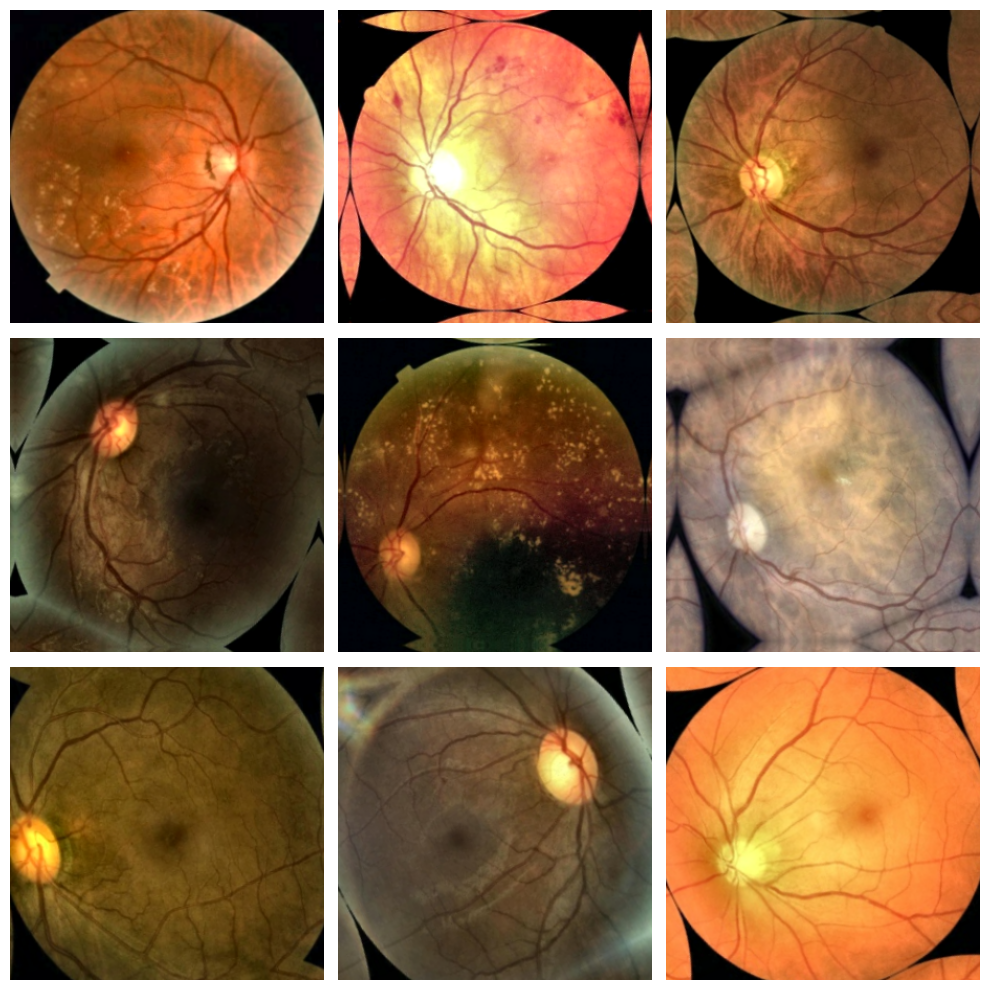

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):

    augmented_images = data_augmentation(images)

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(augmented_images[i].numpy().astype("uint8"))

        plt.axis("off")

plt.tight_layout()
plt.show()